# **1. Perkenalan Dataset**


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

print("Library berhasil diimport!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

Library berhasil diimport!
Pandas version: 2.2.2
NumPy version: 2.0.2


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/TUGAS PIJAK/MSML/heart.csv')

Mounted at /content/drive


In [ ]:
print("Dataset berhasil dimuat!")
print(f"Jumlah baris: {df.shape[0]}, jumlah kolom: {df.shape[1]}")
print("\n5 baris pertama:")
df.head()

Dataset berhasil dimuat!
Jumlah baris: 303, jumlah kolom: 14

5 baris pertama:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [ ]:
df.columns.tolist()

['age',
 'sex',
 'cp',
 'trestbps',
 'chol',
 'fbs',
 'restecg',
 'thalach',
 'exang',
 'oldpeak',
 'slope',
 'ca',
 'thal',
 'target']

# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [ ]:
# Melihat informasi umum dataset
print("=== Informasi Dataset ===")
print(df.info())

print("\n=== Statistik Deskriptif ===")
print(df.describe())

=== Informasi Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB
None

=== Statistik Deskriptif ===
              age         sex          cp    trestbps        chol         fbs  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  303.000000

In [ ]:
# Cek missing values
print("\n=== Missing Values ===")
print(df.isnull().sum())

# Cek duplikasi data
print(f"\nJumlah data duplikat: {df.duplicated().sum()}")


=== Missing Values ===
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Jumlah data duplikat: 1



=== Distribusi Kelas Target (target) ===
target
1    165
0    138
Name: count, dtype: int64


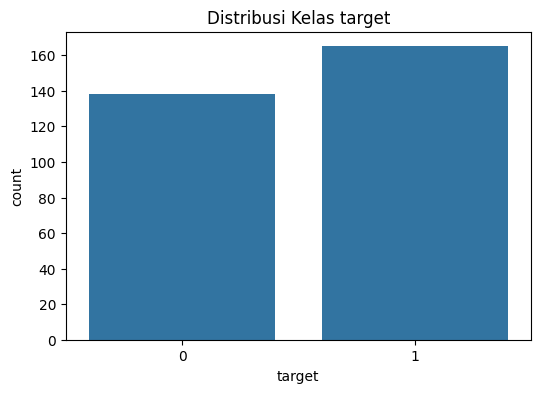

In [ ]:
target_col = 'target'
if target_col in df.columns:
    print(f"\n=== Distribusi Kelas Target ({target_col}) ===")
    print(df[target_col].value_counts())

    # Visualisasi distribusi target
    import matplotlib.pyplot as plt
    import seaborn as sns

    plt.figure(figsize=(6,4))
    sns.countplot(x=target_col, data=df)
    plt.title(f'Distribusi Kelas {target_col}')
    plt.show()
else:
    print(f"\nKolom '{target_col}' tidak ditemukan. Cek nama kolom target Anda:")
    print(df.columns.tolist())

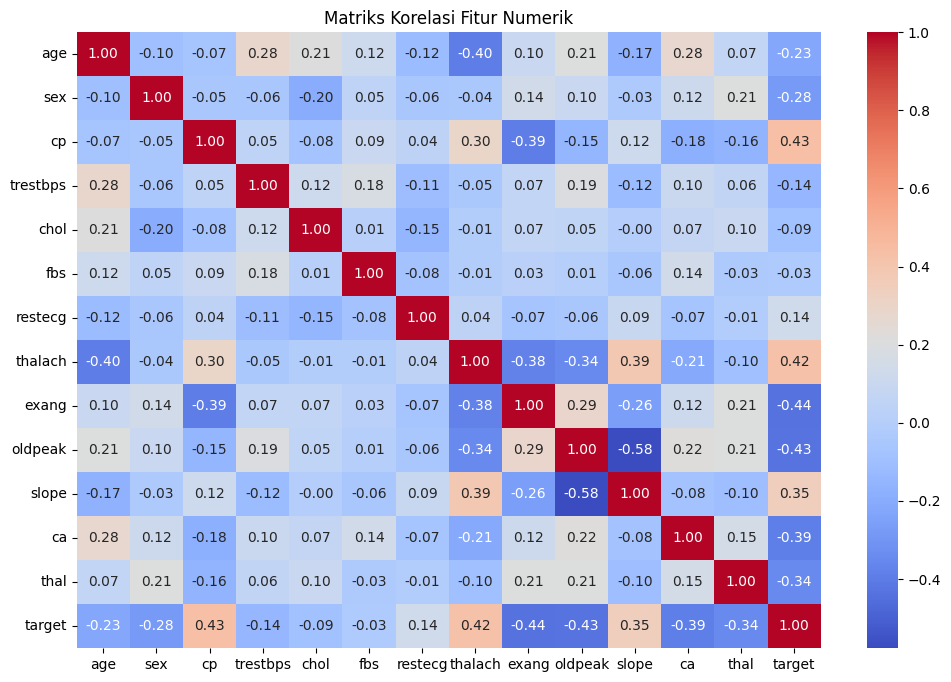

In [ ]:
# Visualisasi korelasi antar fitur numerik
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
if len(numeric_cols) > 1:
    plt.figure(figsize=(12,8))
    sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Matriks Korelasi Fitur Numerik')
    plt.show()

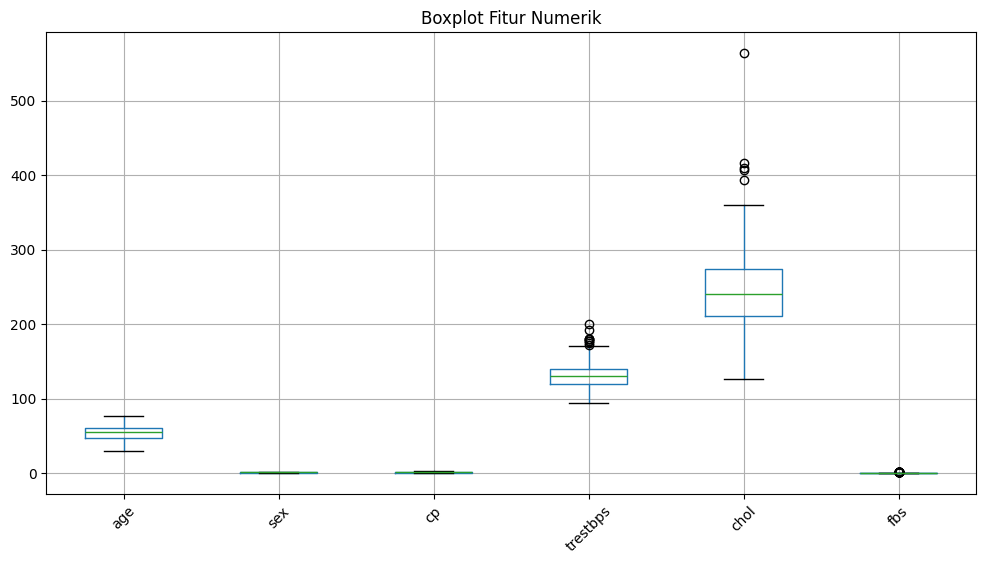

In [ ]:
# Visualisasi boxplot untuk mendeteksi outlier pada fitur numerik
num_cols_to_plot = numeric_cols[:6]  # Plot maksimal 6 kolom agar tidak terlalu padat
df[num_cols_to_plot].boxplot(figsize=(12,6))
plt.title('Boxplot Fitur Numerik')
plt.xticks(rotation=45)
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [ ]:
target_col = 'target'
X = df.drop(target_col, axis=1)
y = df[target_col]

In [ ]:
# 1. Cek missing values
print("Missing values sebelum handling:")
print(X.isnull().sum().sum())

Missing values sebelum handling:
0


In [ ]:
# 2. Hapus duplikat
initial_shape = X.shape
X = X.drop_duplicates()
y = y.loc[X.index]
print(f"Duplikat dihapus: {initial_shape[0] - X.shape[0]} baris")

Duplikat dihapus: 1 baris


In [ ]:
# 3. Standarisasi fitur numerik
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

In [ ]:
# 4. Gabungan
df_clean = X_scaled.copy()
df_clean[target_col] = y.values

In [ ]:
# Simpan hasil preprocessing untuk digunakan di modelling
df_clean.to_csv('heart_preprocessed.csv', index=False)
print("Data preprocessing selesai. Data tersimpan sebagai 'heart_preprocessed.csv'")
print(f"Shape data siap latih: {df_clean.shape}")
print("Contoh 5 baris pertama:")
df_clean.head()

Data preprocessing selesai. Data tersimpan sebagai 'heart_preprocessed.csv'
Shape data siap latih: (302, 14)
Contoh 5 baris pertama:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,0.949794,0.682656,1.976470,0.764066,-0.261285,2.389793,-1.002541,0.018826,-0.698344,1.084022,-2.271182,-0.714911,-2.147955,1
1,-1.928548,0.682656,1.005911,-0.091401,0.067741,-0.418446,0.901657,1.636979,-0.698344,2.118926,-2.271182,-0.714911,-0.513994,1
2,-1.485726,-1.464866,0.035352,-0.091401,-0.822564,-0.418446,-1.002541,0.980971,-0.698344,0.307844,0.979514,-0.714911,-0.513994,1
3,0.174856,0.682656,0.035352,-0.661712,-0.203222,-0.418446,0.901657,1.243374,-0.698344,-0.209608,0.979514,-0.714911,-0.513994,1
4,0.285561,-1.464866,-0.935208,-0.661712,2.080602,-0.418446,0.901657,0.587366,1.431958,-0.382092,0.979514,-0.714911,-0.513994,1


In [ ]:
X = df.drop(target_col, axis=1)
y = df[target_col]

print("=== Cek Missing Values ===")
print(X.isnull().sum().sum(), "missing values pada fitur")
print(y.isnull().sum(), "missing values pada target")

=== Cek Missing Values ===
0 missing values pada fitur
0 missing values pada target


In [ ]:
# Hapus baris dengan missing values jika ada
if X.isnull().sum().sum() > 0 or y.isnull().sum() > 0:
    df = df.dropna()
    X = df.drop(target_col, axis=1)
    y = df[target_col]
    print("Missing values telah dihapus.")

In [ ]:
print("\n=== Hapus Duplikat ===")
print(f"Jumlah baris sebelum: {df.shape[0]}")
df = df.drop_duplicates()
print(f"Jumlah baris setelah: {df.shape[0]}")
X = df.drop(target_col, axis=1)
y = df[target_col]


=== Hapus Duplikat ===
Jumlah baris sebelum: 303
Jumlah baris setelah: 302


In [ ]:
print("\n=== Standarisasi Fitur ===")
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
print("Standarisasi selesai.")


=== Standarisasi Fitur ===
Standarisasi selesai.


In [ ]:
print("\n=== Deteksi Outlier (IQR) ===")
Q1 = X_scaled.quantile(0.25)
Q3 = X_scaled.quantile(0.75)
IQR = Q3 - Q1
outlier_mask = (X_scaled < (Q1 - 1.5*IQR)) | (X_scaled > (Q3 + 1.5*IQR))
print("Jumlah outlier per fitur:")
print(outlier_mask.sum())


=== Deteksi Outlier (IQR) ===
Jumlah outlier per fitur:
age          0
sex          0
cp           0
trestbps     9
chol         5
fbs         45
restecg      0
thalach      1
exang        0
oldpeak      5
slope        0
ca          24
thal         2
dtype: int64


In [ ]:
print("\n=== Gabungkan dan Simpan ===")
df_clean = X_scaled.copy()
df_clean[target_col] = y.values
df_clean.to_csv('heart_preprocessed.csv', index=False)
print("Data preprocessing selesai. File 'heart_preprocessed.csv' siap digunakan.")

df_clean.head()


=== Gabungkan dan Simpan ===
Data preprocessing selesai. File 'heart_preprocessed.csv' siap digunakan.


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,0.949794,0.682656,1.976470,0.764066,-0.261285,2.389793,-1.002541,0.018826,-0.698344,1.084022,-2.271182,-0.714911,-2.147955,1
1,-1.928548,0.682656,1.005911,-0.091401,0.067741,-0.418446,0.901657,1.636979,-0.698344,2.118926,-2.271182,-0.714911,-0.513994,1
2,-1.485726,-1.464866,0.035352,-0.091401,-0.822564,-0.418446,-1.002541,0.980971,-0.698344,0.307844,0.979514,-0.714911,-0.513994,1
3,0.174856,0.682656,0.035352,-0.661712,-0.203222,-0.418446,0.901657,1.243374,-0.698344,-0.209608,0.979514,-0.714911,-0.513994,1
4,0.285561,-1.464866,-0.935208,-0.661712,2.080602,-0.418446,0.901657,0.587366,1.431958,-0.382092,0.979514,-0.714911,-0.513994,1


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import sys

def preprocess_heart(input_path='heart.csv', output_path='heart_preprocessed.csv', target_col='target'):
    # Load dataset
    df = pd.read_csv('/content/drive/MyDrive/TUGAS PIJAK/MSML/heart.csv')
    print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")

    # Pisahkan fitur dan target
    if target_col not in df.columns:
        raise ValueError(f"Kolom target '{target_col}' tidak ditemukan. Kolom yang ada: {df.columns.tolist()}")

    X = df.drop(target_col, axis=1)
    y = df[target_col]

    # 1. Handling missing values
    print("\n=== Handling Missing Values ===")
    if X.isnull().sum().sum() > 0 or y.isnull().sum() > 0:
        before = df.shape[0]
        df = df.dropna()
        after = df.shape[0]
        print(f"Menghapus {before - after} baris yang mengandung missing values")
        X = df.drop(target_col, axis=1)
        y = df[target_col]
    else:
        print("Tidak ada missing values.")

    # 2. Menghapus data duplikat
    print("\n=== Handling Duplicates ===")
    before = df.shape[0]
    df = df.drop_duplicates()
    after = df.shape[0]
    print(f"Menghapus {before - after} baris duplikat")
    X = df.drop(target_col, axis=1)
    y = df[target_col]

    # 3. Standarisasi fitur
    print("\n=== Standarisasi Fitur ===")
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
    print("Standarisasi selesai.")

    # 4. Deteksi outlier
    print("\n=== Deteksi Outlier (IQR) ===")
    Q1 = X_scaled.quantile(0.25)
    Q3 = X_scaled.quantile(0.75)
    IQR = Q3 - Q1
    outlier_mask = (X_scaled < (Q1 - 1.5*IQR)) | (X_scaled > (Q3 + 1.5*IQR))
    outlier_count = outlier_mask.sum().sum()
    print(f"Total outlier terdeteksi: {outlier_count}")

    # Gabungkan
    df_clean = X_scaled.copy()
    df_clean[target_col] = y.values

    # Simpan ke CSV
    df_clean.to_csv(output_path, index=False)
    print(f"\nPreprocessing selesai. Data bersih disimpan ke {output_path}")
    print(f"Shape data akhir: {df_clean.shape}")

    return df_clean

if __name__ == "__main__":

    input_file = sys.argv[1] if len(sys.argv) > 1 else 'heart.csv'
    output_file = sys.argv[2] if len(sys.argv) > 2 else 'heart_preprocessed.csv'
    target = sys.argv[3] if len(sys.argv) > 3 else 'target'
    preprocess_heart(input_file, output_file, target)

Dataset loaded: 303 rows, 14 columns

=== Handling Missing Values ===
Tidak ada missing values.

=== Handling Duplicates ===
Menghapus 1 baris duplikat

=== Standarisasi Fitur ===
Standarisasi selesai.

=== Deteksi Outlier (IQR) ===
Total outlier terdeteksi: 91

Preprocessing selesai. Data bersih disimpan ke /root/.local/share/jupyter/runtime/kernel-de03b732-a168-4353-950f-9f09ed1fd7aa.json
Shape data akhir: (302, 14)
